In [275]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [276]:
df = pd.read_csv(r"D:\ML\DataSet\Titanic_Dataset.csv",usecols=['Age','Fare','Survived'])
#usecols is a parameter that we can use to select the required columns for further working

In [277]:
df.sample(3)

,Survived,Age,Fare
869,1,4.0,11.1333
418,0,30.0,13.0000
327,1,36.0,13.0000


In [278]:
df.shape[0] #this will give me the no. of rows

891

In [279]:
df.dropna(inplace=True)

#dropna() → This method removes any rows (by default) that contain missing values (NaN).

In [280]:
df.shape[0]

714

In [281]:
df.sample(5)

,Survived,Age,Fare
137,0,37.0,53.10
319,1,40.0,134.50
872,0,33.0,5.00
106,1,21.0,7.65
70,0,32.0,10.50


In [282]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [283]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [284]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [285]:
clf = DecisionTreeClassifier()

In [286]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [287]:
accuracy_score(y_test,y_pred)

0.6293706293706294

In [288]:
np.mean(cross_val_score(clf,X,y,cv=10,scoring='accuracy'))

np.float64(0.6330985915492957)

-------

In [289]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile',quantile_method='linear')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile',quantile_method='linear')

#in future the default behaviour of quantile is going to change, so, use this quantile_method parameter as extra

In [290]:
trf =ColumnTransformer([
    ('first',kbin_age,[0]),     #in X_train age is column 1 so, it's index is 0
    ('second',kbin_fare,[1])
])

In [291]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

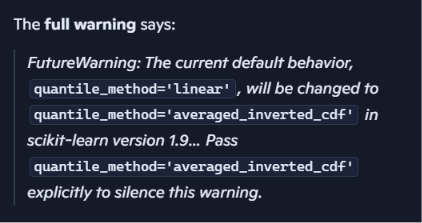

In [292]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15, quantile_method='linear'),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15, quantile_method='linear')}

In [293]:
trf.named_transformers_['first'].n_bins_
#this will tell about no. of the bins that are being created

array([15])

In [294]:
trf.named_transformers_['first'].bin_edges_

#this will tell about the boundry of the bins

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

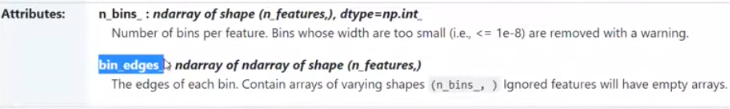

In [295]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
               13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
               51.4792,  76.2917, 108.9   , 512.3292])                   ],
      dtype=object)

In [296]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [297]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

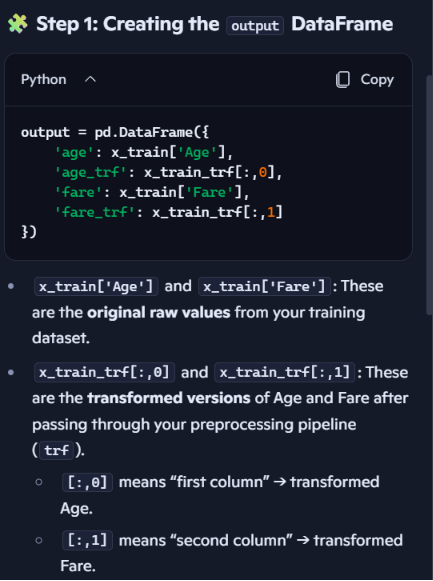
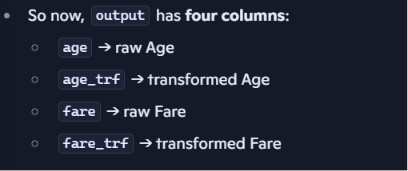

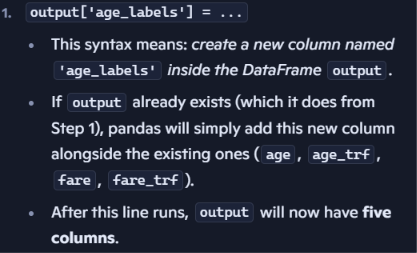
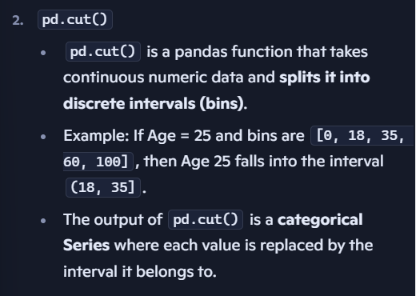
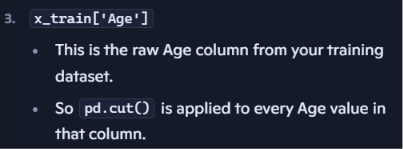
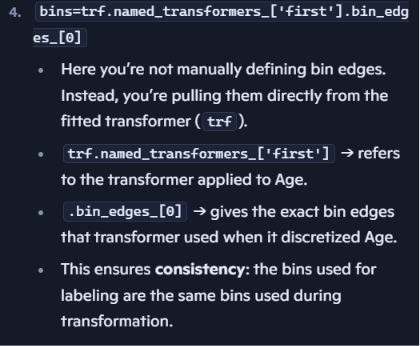
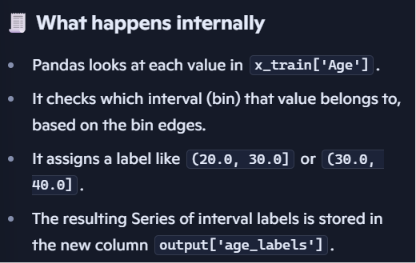

In [298]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
395,22.0,4.0,7.7958,2.0,"(21.0, 23.0]","(7.775, 7.896]"
57,28.5,7.0,7.2292,0.0,"(28.0, 30.0]","(0.0, 7.25]"
243,22.0,4.0,7.1250,0.0,"(21.0, 23.0]","(0.0, 7.25]"
113,20.0,3.0,9.8250,4.0,"(19.0, 21.0]","(8.158, 10.5]"
188,40.0,11.0,15.5000,7.0,"(38.0, 42.0]","(14.454, 18.75]"


In [299]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)

y_pred2 = clf.predict(X_test_trf)

In [300]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [301]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6288928012519561)

In [302]:
# Below is the function for discretization in which all work is done in same place

# We will just have to pass no. of bins and the methods going to be used

def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='green')
    plt.title("Fare")

    plt.show()
  

0.6359350547730829


d:\ML\ML_venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\ML\ML_venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


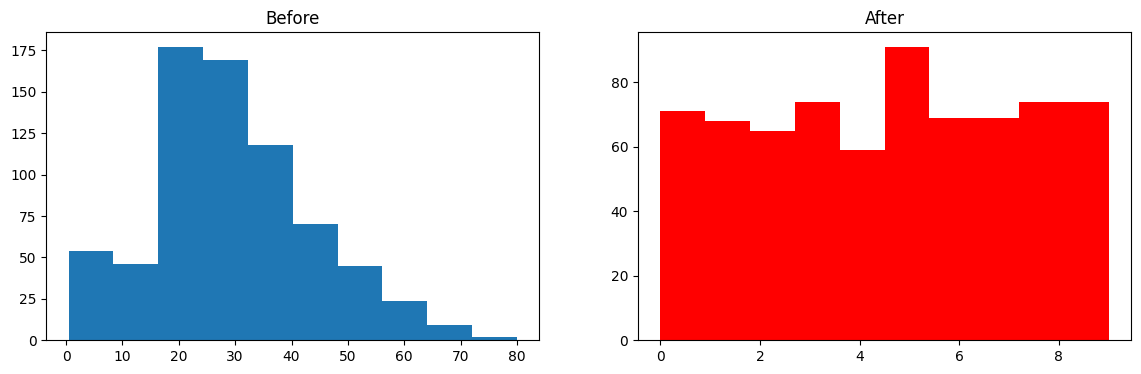

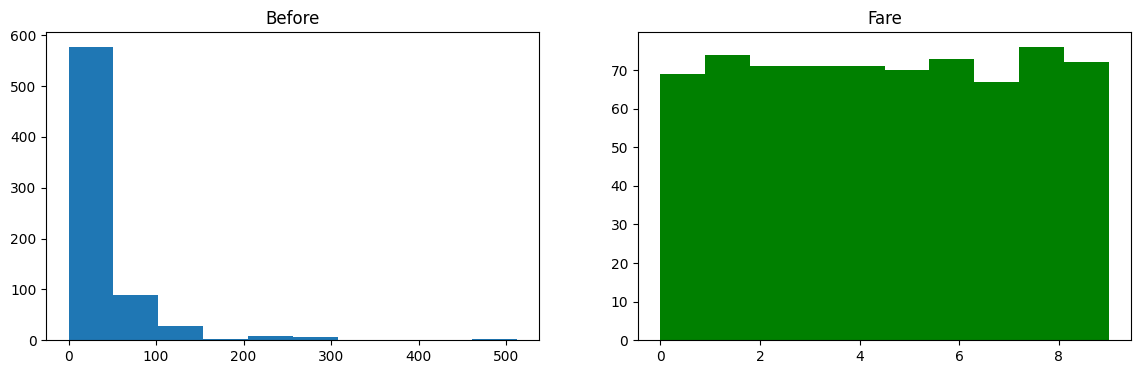

In [303]:
discretize(10,'quantile')

0.630281690140845


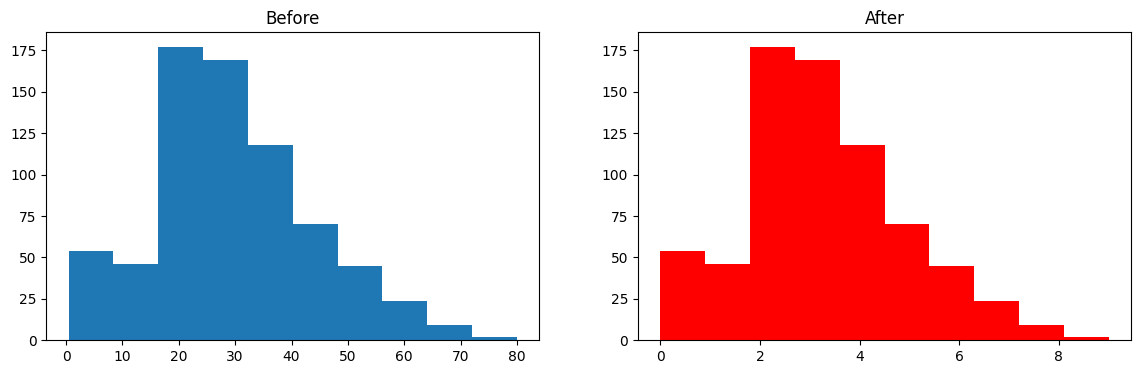

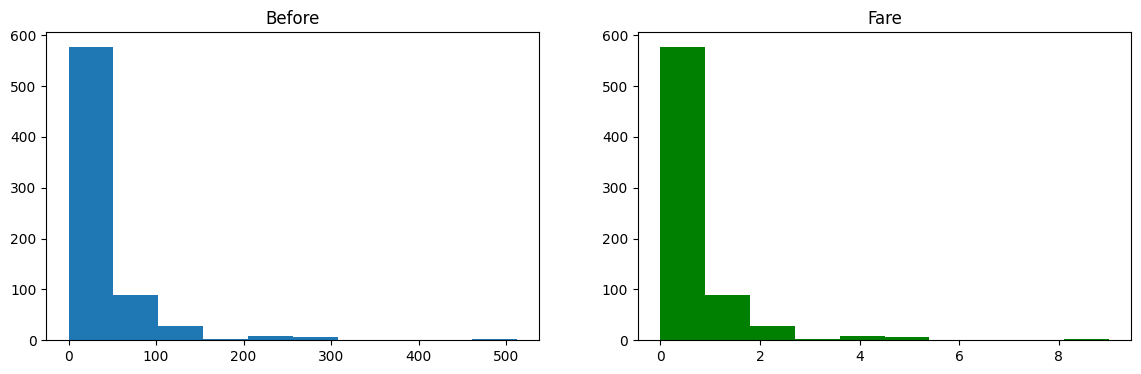

In [304]:
discretize(10,'uniform')

0.6303208137715179


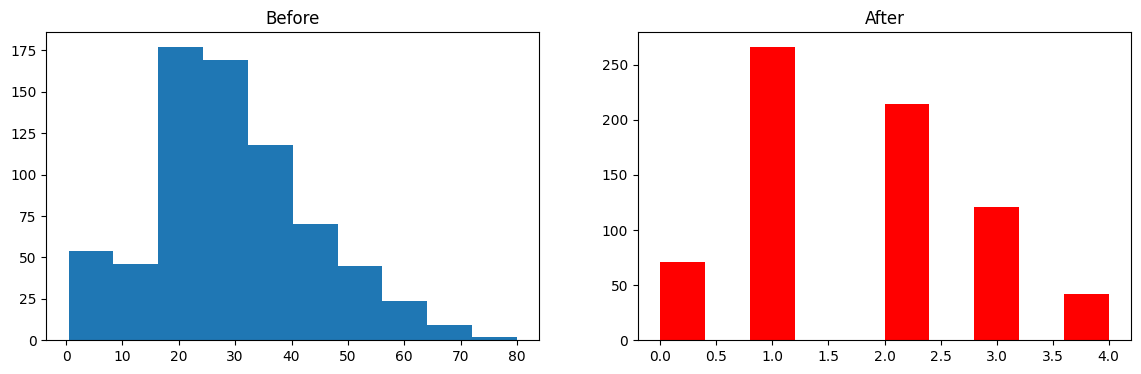

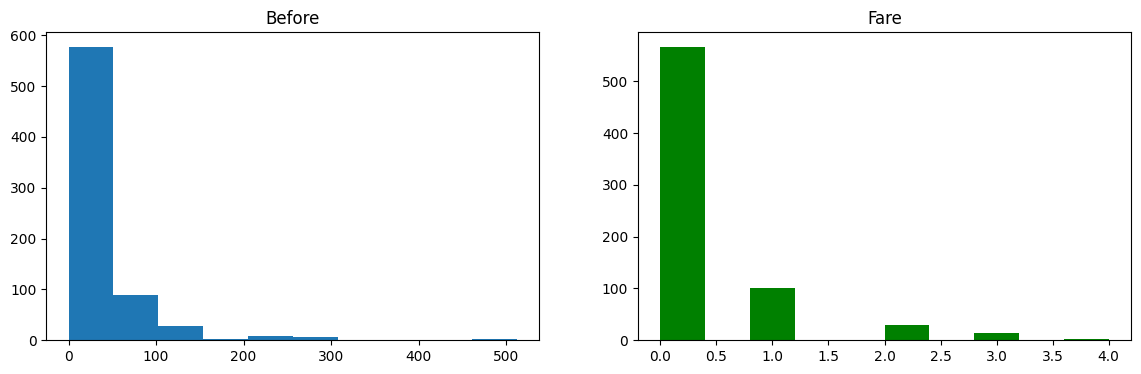

In [305]:
discretize(5,'kmeans')      #the no. of bins should atleast start from 2

-----------
-----------
-------------
-------------

now, we are going to do study for Binarization

In [306]:
df1 = pd.read_csv(r"D:\ML\DataSet\Titanic_Dataset.csv")[['Age','Fare', 'SibSp', 'Parch', 'Survived']]

#other than the parameter usecols = ['',..] we can also use this way to use certain columns
#also , this arranges the column in the order we have written the column name. 

In [307]:
df1.sample(3)

,Age,Fare,SibSp,Parch,Survived
697,NaN,7.7333,0,0,1
74,32.0,56.4958,0,0,1
366,60.0,75.2500,1,0,1


In [308]:
df1.dropna(inplace=True)

In [309]:
df1.isnull().sum()

Age         0
Fare        0
SibSp       0
Parch       0
Survived    0
dtype: int64

In [310]:
df1.head()

,Age,Fare,SibSp,Parch,Survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0


In [311]:
df1['Family'] = df1['SibSp']+df1['Parch']
#this helps us to generate a whole new column which have the elements combination of the 2 columns
#also, the elements of the columns are numerical

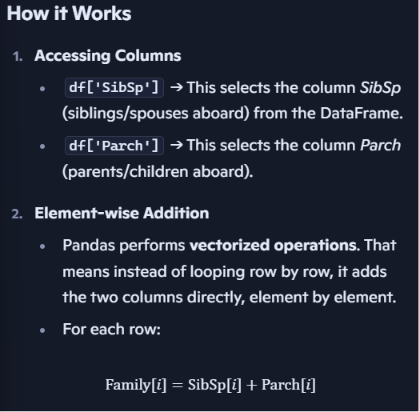

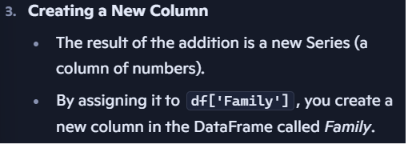

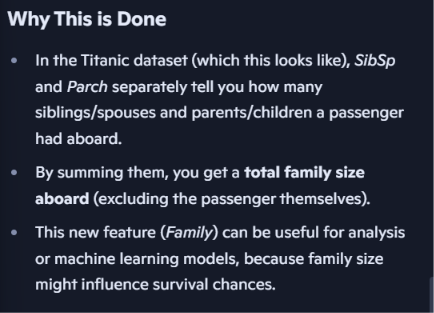

In [312]:
df1.head()

,Age,Fare,SibSp,Parch,Survived,Family
0,22.0,7.2500,1,0,0,1
1,38.0,71.2833,1,0,1,1
2,26.0,7.9250,0,0,1,0
3,35.0,53.1000,1,0,1,1
4,35.0,8.0500,0,0,0,0


In [313]:
df1.drop(columns=['SibSp','Parch'],inplace=True)

In [314]:
df1.sample(3)

,Age,Fare,Survived,Family
872,33.0,5.00,0,0
145,19.0,36.75,0,2
280,65.0,7.75,0,0


In [315]:
df1 = df1[['Age','Family' ,'Fare', 'Survived']]
#this is the easy way to change the ordering of the columns

In [316]:
df1.sample(3)

,Age,Family,Fare,Survived
600,24.0,3,27.0000,1
291,19.0,1,91.0792,1
460,48.0,0,26.5500,1


In [317]:
X1 = df1.drop(columns=['Survived'])
y1 = df1['Survived']

In [318]:
X1_train,X1_test,y1_train,y1_test = train_test_split(X1,y1,test_size=0.2,random_state=42)

In [319]:
X1_train.head()

,Age,Family,Fare
328,31.0,2,20.5250
73,26.0,1,14.4542
253,30.0,1,16.1000
719,33.0,0,7.7750
666,25.0,0,13.0000


In [320]:
# Without binarizatibn

clf = DecisionTreeClassifier()

clf.fit(X1_train,y1_train)

y1_pred = clf.predict(X1_test)

accuracy_score(y1_test, y1_pred)

0.6293706293706294

In [321]:
np.mean(cross_val_score(clf,X1,y1,cv=10,scoring='accuracy'))

np.float64(0.6401017214397496)

In [322]:
# Applying the Binarization

from sklearn.preprocessing import Binarizer

In [323]:
trf1 = ColumnTransformer([
    ('bin',Binarizer(copy=False),['Family']),
],remainder='passthrough')

In [324]:
X1_train_trf1 = trf1.fit_transform(X1_train)
X1_test_trf1 = trf1.transform(X1_test)

In [325]:
pd.DataFrame(X1_train_trf1,columns=['Family','Age','Fare'])

,Family,Age,Fare
0,1.0,31.0,20.5250
1,1.0,26.0,14.4542
2,1.0,30.0,16.1000
3,0.0,33.0,7.7750
4,0.0,25.0,13.0000
...,...,...,...
566,1.0,46.0,61.1750
567,0.0,25.0,13.0000
568,0.0,41.0,134.5000
569,1.0,33.0,20.5250


In [326]:
clf = DecisionTreeClassifier()
clf.fit(X1_train_trf1,y1_train)
y1_pred2 = clf.predict(X1_test_trf1)

accuracy_score(y1_test, y1_pred2)

0.6293706293706294

In [328]:
X1_trf1 = trf1.fit_transform(X1)
np.mean(cross_val_score(clf,X1_trf1,y1,cv=10,scoring='accuracy'))

np.float64(0.6303599374021909)